# Ejercicios Prácticos - Evaluación de modelos y métricas de rendimiento avanzadas

##### II DIPLOMA DE EXPERTO EN APRENDIZAJE AUTOMÁTICO AVANZADO EN PYTHON
#### Alumno: Pablo Fazio Arrabal

---

## Ejercicios Básicos

1. Considere el conjunto de muestras ionosphere.csv disponible en el Campus Virtual y realice las siguientes tareas:

**a)** Preprocese el conjunto de muestras y estandarice las muestras.

**b)** Analice el rendimiento de un modelo basado en regresión logística con 200 épocas de entrenamiento y método “lbfgs”. Dibuje las curvas de exactitud en entrenamiento y en test en función del porcentaje de muestras de entrenamiento y las desviaciones típicas. Para ello, considere conjuntos de entrenamiento del 10, 20, 30, 40, 50, 60, 70, 80 y 90 por ciento del conjunto de muestras y utilice 12 pliegues en el método *learning_curve*. ¿Cuál configuración cree que es la mejor?. ¿Existe alguna configuración en la que se produzca sobreajuste? ¿en cuál? ¿y subajuste? Razone todas sus respuestas.

**c)** Analice el rendimiento de un modelo basado en regresión logística con 200 épocas de entrenamiento y método “lbfgs”. Dibuje las curvas de exactitud en entrenamiento y test en función de $C$ y las desviaciones típicas. Emplee 16 valores equiespaciados del parámetro de regularización en el intervalo $C = [10^{−5}, 1]$ usando escala logarítmica. Utilice 10 pliegues en el método *validation_curve*. ¿Cuál configuración cree que es la mejor?¿Existe alguna configuración en la que se produzca sobreajuste? ¿en cuál? ¿y subajuste? Razone todas sus respuestas.


In [1]:
# APARTADO A)

import pandas as pd
import numpy as np

# Cargamos el archivo ionosphere.csv como hemos venido haciendo en estas prácticas

df_ion = pd.read_csv('/content/ionosphere.csv', header = None)

# Comprobamos que no hay ningún valor desconocido
# df_ion.isnull().sum()

# Separamos los conjuntos de variables de entrada X y la columna de clase y
X = df_ion.loc[:, 0:33]
y = df_ion.loc[:, 34]

# Verificamos las etiquetas de las clases deseadas ('b' - bad y 'g' - good)
np.unique(y)

array(['b', 'g'], dtype=object)

In [2]:
# Aplicamos un mapeo en las clases deseadas usando LabelEncoder
from sklearn.preprocessing import LabelEncoder

mapeador_clase = LabelEncoder()
y = mapeador_clase.fit_transform(y)

np.unique(y)

array([0, 1])

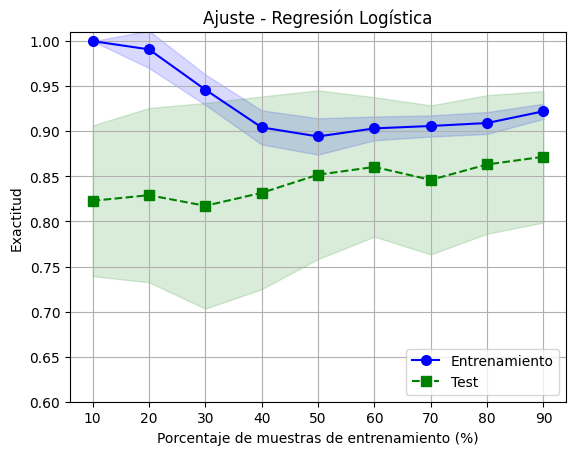

In [3]:
# APARTADO B)

import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Definimos un modelo de regresión logística con los datos requeridos y estandarizamos
pipeline_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=200, solver='lbfgs', random_state=10)
)

# Defino un vector de porcentajes desde 0.1 a 0.9 (aumentando en 0.1 cada vez)
porcentajes = np.linspace(0.1, 0.9, 9)

# Usamos el método learning_curve con nuestro modelo y muestras, 12 pliegues
# requeridos y los porcentajes definidos
tamaños_conjEnt, rendimientos_ent, rendimientos_test = learning_curve(
    estimator=pipeline_lr,
    X=X,
    y=y,
    train_sizes=porcentajes,
    cv=12
)

# Calculamos medias y desviaciones típicas de rendimiento para cada pliegue
media_ent = np.mean(rendimientos_ent, axis=1)
desvT_ent = np.std(rendimientos_ent, axis=1)
media_test = np.mean(rendimientos_test, axis=1)
desvT_test = np.std(rendimientos_test, axis=1)

eje_x_porcentajes = porcentajes * 100

# Dibujamos rendimientos medios en función del porcentaje del conjunto de entrenamiento
plt.plot(eje_x_porcentajes, media_ent,
         color='blue', marker='o',
         markersize=7, label='Entrenamiento')
plt.plot(eje_x_porcentajes, media_test,
         color='green', linestyle='--',
         marker='s', markersize=7,
         label='Test')

# Pintamos desviaciones típicas
plt.fill_between(eje_x_porcentajes,
                 media_ent + desvT_ent,
                 media_ent - desvT_ent,
                 alpha=0.15, color='blue')
plt.fill_between(eje_x_porcentajes,
                 media_test + desvT_test,
                 media_test - desvT_test,
                 alpha=0.15, color='green')

plt.grid()
plt.title('Ajuste - Regresión Logística')
plt.xlabel('Porcentaje de muestras de entrenamiento (%)')
plt.ylabel('Exactitud')
plt.legend(loc='lower right')
plt.ylim([0.60, 1.01])
plt.show()

- ¿Cuál configuración cree que es la mejor?

Yo creo que la mejor configuración es entorno al **80%-20% ó 90%-10% de división** entre test y entrenamiento. Esto es debido a que es donde se obtiene una mejor precisión en el conjunto de test y se nota que generaliza mejor.

- ¿Existe alguna configuración en la que
se produzca sobreajuste? ¿en cuál?

Es fácil ver que cuando tenemos muy pocas muestras de entrenamiento (primeros puntos de la gráfica, 10-90 ó 20-80) se produce un sobreajuste al obtener casi 100% de precisión en las muestras de entrenamiento (las memoriza) y muy poca precisión en las muestras de test, es decir, no generaliza correctamente.

- ¿Y subajuste?

No diría que hay un subajuste claro pues a mayor muestra de entrenamiento, la precisión tanto de entrenamiento como de test se mejora.

In [4]:
# APARTADO C)

# En primer lugar, vamos a definir el rango de valores que probaremos
# del hiperparámetro C

# Probamos 16 valores del hiperparámetro C, equiespaciados desde 10^-5 hasta 1
# usando escala logarítmica
rango_param_C = np.logspace(-5, 0, 16)

# Debemos ver como se denomina el parámetro C en el modelo de regresión logística
# para usarlo en validation_curve

pipeline_lr.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'standardscaler', 'logisticregression', 'standardscaler__copy', 'standardscaler__with_mean', 'standardscaler__with_std', 'logisticregression__C', 'logisticregression__class_weight', 'logisticregression__dual', 'logisticregression__fit_intercept', 'logisticregression__intercept_scaling', 'logisticregression__l1_ratio', 'logisticregression__max_iter', 'logisticregression__multi_class', 'logisticregression__n_jobs', 'logisticregression__penalty', 'logisticregression__random_state', 'logisticregression__solver', 'logisticregression__tol', 'logisticregression__verbose', 'logisticregression__warm_start'])

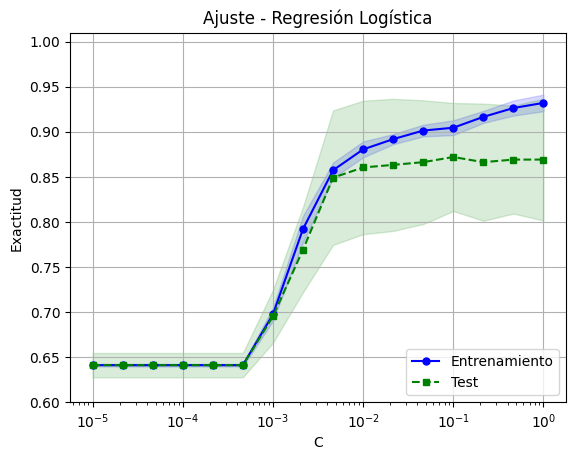

In [5]:
from sklearn.model_selection import validation_curve

# Usamos el método validation_curve con nuestro modelo y muestras, 10 pliegues
# requeridos y rangos definidos

rendimientos_ent, rendimientos_test = validation_curve(
    estimator=pipeline_lr,
    X=X,
    y=y,
    param_name='logisticregression__C',
    param_range=rango_param_C,
    cv=10
)

# Calculamos medias y desviaciones típicas de rendimiento para cada pliegue

media_ent = np.mean(rendimientos_ent, axis=1)
desvT_ent = np.std(rendimientos_ent, axis=1)
media_test = np.mean(rendimientos_test, axis=1)
desvT_test = np.std(rendimientos_test, axis=1)

# Dibujamos rendimientos medios y desviaciones típicas en función del valor de C

plt.plot(rango_param_C, media_ent,
         color='blue', marker='o',
         markersize=5, label='Entrenamiento')
plt.fill_between(rango_param_C, media_ent + desvT_ent,
                 media_ent - desvT_ent, alpha=0.15,
                 color='blue')
plt.plot(rango_param_C, media_test,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Test')
plt.fill_between(rango_param_C,
                 media_test + desvT_test,
                 media_test - desvT_test,
                 alpha=0.15, color='green')
plt.grid()

plt.legend(loc='lower right')
plt.xlabel("C")
plt.ylabel('Exactitud')
plt.title('Ajuste - Regresión Logística')
plt.xscale('log')
plt.ylim([0.6, 1.01])
plt.show()


- ¿Cuál configuración cree que es la mejor?

La mejor configuración se encuentra en $C = 10^{-1}$. En este valor de $C$ se alcanza el mejor valor de exactitud en test y está suficientemente regularizado para no aprenderse el ruido en entrenamiento.

- ¿Existe alguna configuración en la que
se produzca sobreajuste? ¿en cuál?

Cuando $C$ se acerca a $1$, se produce un claro sobreajuste. Se ve como la precisión en entrenamiento aumenta hasta llegar a $1$ mientras que la precisión de test se estanca.

- ¿Y subajuste?

Sí, se produce un claro subajuste en los valores más bajos de $C$, concretamente en el rango de $10^{-5}$ a $10^{-3}$. Aquí, ambas curvas (tanto entrenamiento como test) toma valores muy bajos de exactitud, al ser el modelo muy simple.

2. Considerando el conjunto de muestras ionosphere.csv disponible en el Campus Virtual, realice las siguientes tareas:

    **a)** Determine de la forma que crea más fiable qué modelo de clasificación es mejor para este problema. Pruebe regresión logística (usando rasgos estandarizados), K vecinos más cercanos (usando rasgos estandarizados) y bosques aleatorios. Justifique su elección apoyándose en un diagrama de caja. Los hiperparámetros a probar serán:

    - Regresión logística: C = {0.001, 0.01, 0.1, 1.0,10.0, 100.0}

    - Bosques aleatorios: Nº árboles = {10,50,100,200,400}
    
    - K vecinos más cercanos: Nº vecinos = {2,4,10,20,50}

    **b)** Estudie el rendimiento de dos de los hiperparámetros del modelo determinado en el apartado anterior, use el hiperparámetro especificado en el apartado anterior y otro que considere oportuno. Indique cuál es la mejor configuración y cuál la peor. Ilustre y justifique sus razonamientos utilizando la gráfica o diagrama que crea adecuada.

In [6]:
# APARTADO A)

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Vamos a usar validación cruzada anidada para comparar el rendimiento entre
# KNN, los árboles de decisión y la regresión logística

# Vamos a calcular en primer lugar los rendimientos de la regresión logística

rango_param_C = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

pipe_RL = make_pipeline(StandardScaler(),
                        LogisticRegression(random_state=1,
                                           max_iter=100))
# Bucle interno
busqRejilla = GridSearchCV(estimator=pipe_RL,
                  param_grid=[{'logisticregression__C': rango_param_C}],
                  scoring='accuracy',
                  cv=2)

# Bucle externo
rendimientosRL = cross_val_score(busqRejilla, X, y,
                         scoring='accuracy', cv=10)
print('Exactitud RL: %.3f +/- %.3f' % (np.mean(rendimientosRL),
                                      np.std(rendimientosRL)))

# Guardaremos este dato para el ejercicio 3
busqRejilla.fit(X, y)
mejorC = busqRejilla.best_params_['logisticregression__C']

Exactitud RL: 0.866 +/- 0.063


In [7]:
from sklearn.ensemble import RandomForestClassifier

# Calculamos ahora los rendimientos de los bosques aleatorios

rango_param_num_arboles = [10, 50, 100, 200, 400]

# Bucle interno
busqRejilla = GridSearchCV(estimator=RandomForestClassifier(
                      random_state=0),
                  param_grid=[{'n_estimators': rango_param_num_arboles}],
                  scoring='accuracy',
                  cv=2)

# Bucle externo
rendimientosArbol = cross_val_score(busqRejilla, X, y,
                         scoring='accuracy', cv=10)
print('Exactitud RF: %.3f +/- %.3f' % (np.mean(rendimientosArbol),
                                      np.std(rendimientosArbol)))

Exactitud RF: 0.934 +/- 0.056


In [8]:
from sklearn.neighbors import KNeighborsClassifier

# Por último, calculemos el rendimiento de K vecinos más cercanos

rango_num_vecinos = [2, 4, 10, 20, 50]

pipe_KNN = make_pipeline(StandardScaler(),
                        KNeighborsClassifier())

# Bucle interno
busqRejilla = GridSearchCV(estimator=pipe_KNN,
                  param_grid=[{'kneighborsclassifier__n_neighbors': rango_num_vecinos}],
                  scoring='accuracy',
                  cv=2)

# Bucle externo
rendimientosKNN = cross_val_score(busqRejilla, X, y,
                         scoring='accuracy', cv=10)
print('Exactitud KNN: %.3f +/- %.3f' % (np.mean(rendimientosKNN),
                                      np.std(rendimientosKNN)))


Exactitud KNN: 0.892 +/- 0.044


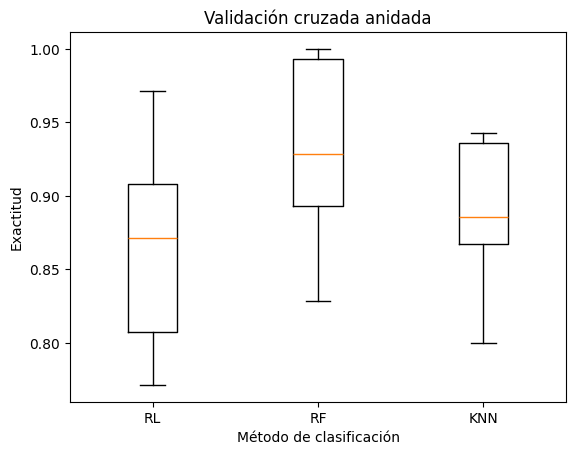

In [9]:
# Visualizamos los rendimientos obtenidos mediante un diagrama de cajas

fig, ax = plt.subplots()

ax.boxplot([rendimientosRL, rendimientosArbol, rendimientosKNN])

ax.set_xticklabels(["RL", "RF", "KNN"], fontsize=10)
ax.set_ylabel("Exactitud")
ax.set_xlabel("Método de clasificación")
ax.set_title('Validación cruzada anidada')
plt.show()

Como vemos en el diagrama de caja anterior, la mejor elección es la de **bosques aleatorios**, con la que se obtiene una mejor precisión mediana.

In [10]:
# APARTADO B)

# Tomamos como clasificador los bosques aleatorios y estudiaremos su rendimiento
# en función del número de árboles y de la máxima profundidad permitida a dichos
# árboles

rango_param_num_arboles = [10, 50, 100, 200, 400]

rango_param_depth = [1, 2, 3, 4, 5, 6, 7]

# Definimos la rejilla para la búsqueda de la mejor combinación de valores

rejilla_param = [{'n_estimators' : rango_param_num_arboles, 'max_depth' : rango_param_depth}]

busqRejilla = GridSearchCV(estimator=RandomForestClassifier(
                      random_state=0),
                  param_grid=rejilla_param,
                  scoring='accuracy',
                  cv=10,
                  n_jobs=-1)
busqRejilla = busqRejilla.fit(X, y)

# GridSearchCV proporciona la función best_params_ que nos permite encontrar la
# mejor configuración de hiperparámetros

print("Mejor configuración:", busqRejilla.best_params_)
print("Exactitud media de la mejor configuración: ", busqRejilla.best_score_)


Mejor configuración: {'max_depth': 7, 'n_estimators': 50}
Exactitud media de la mejor configuración:  0.9457142857142857


In [11]:
resultados = pd.DataFrame(busqRejilla.cv_results_)

# Para encontrar visualmente la peor configuración podemos construir
# la matriz con las precisiones de cada configuración

matriz_rendimientos = resultados.pivot(
    index="param_max_depth",
    columns="param_n_estimators",
    values="mean_test_score"
)

matriz_rendimientos

param_n_estimators,10,50,100,200,400
param_max_depth,,,,,
1,0.837619,0.860476,0.854762,0.851905,0.857619
2,0.888968,0.906111,0.911746,0.914683,0.911825
3,0.908889,0.920238,0.928730,0.931587,0.931667
4,0.931587,0.920159,0.923016,0.925873,0.934444
5,0.931429,0.925873,0.920159,0.925873,0.934444
6,0.934365,0.934365,0.931429,0.937143,0.931508
7,0.931508,0.945714,0.937143,0.937143,0.931508


De esta forma, vemos que la peor configuración es aquella con **10 árboles** y **1 de profundidad máxima**.

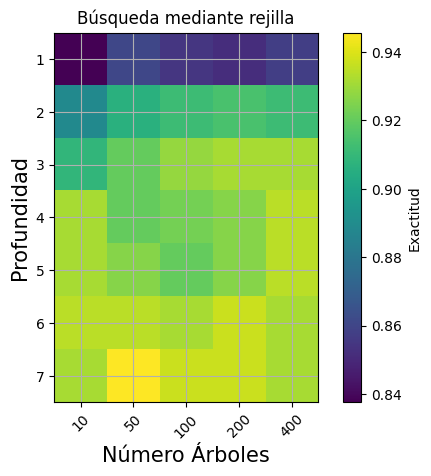

In [12]:
# Graficamos los valores en forma de matriz de colores para una mejor visualización

plt.imshow(matriz_rendimientos)
plt.xticks(ticks = np.arange(len(rango_param_num_arboles)),
           labels=[x for x in rango_param_num_arboles],
           rotation = 45)
plt.xlabel("Número Árboles", fontsize=15)

plt.yticks(np.arange(len(rango_param_depth)),
           labels=[x for x in rango_param_depth])
plt.ylabel("Profundidad", fontsize=15)

plt.title('Búsqueda mediante rejilla')
plt.colorbar(label='Exactitud')
plt.grid()
plt.show()

Es sencillo observar que cuanto mayor profundidad tengan dichos árboles, mejor precisión se obtiene. Además, podemos ver que la profundidad es un valor más significativo que el número de árboles, de forma que con misma profundidad un aumento en el número de árboles no varía tanto la exactitud del clasificador. Alrededor de 50 árboles es un número óptimo.

3. Dibuje la curva ROC del peor método del primer apartado del ejercicio anterior usando su mejor configuración. Comente los resultados.

    **a)** ¿Es capaz de lograr un resultado perfecto en términos de TPR? ¿Qué significaría esa situación? En caso de que lo consiga, ¿qué efectos produce respecto de la detección de muestras de la clase positiva y negativa?

    **b)** ¿Es capaz de lograr un resultado perfecto en términos de FPR? ¿Qué significaría esa situación? En caso de que lo consiga, ¿qué efectos produce respecto de la detección de muestras de la clase positiva y negativa?

    **c)** Imagine que para usted es prioritario detectar las muestras cuya clase deseada es la 1 (positiva), ¿cree que este modelo podría llegar a realizar esta tarea con un alto grado de confianza? Razone su respuesta.

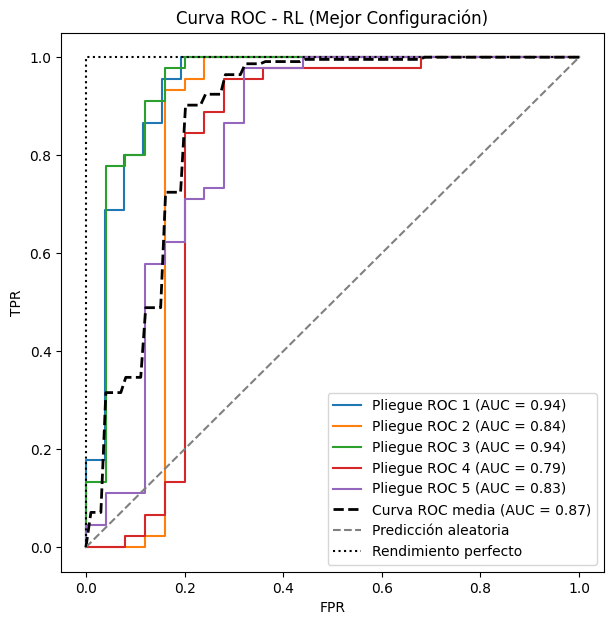

In [13]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

X = df_ion.loc[:, 0:33]
y = df_ion.loc[:, 34]
mapeador_clase = LabelEncoder()
y = mapeador_clase.fit_transform(y)

# El peor método en el ejercicio anterior era el de regresión logística. En ese
# momento ya guardamos la mejor configuración del hiperparámetro C en 'mejorC'

pipe_RL = make_pipeline(StandardScaler(),
                        LogisticRegression(random_state=10,
                                           C=mejorC))

kPliegues = list(StratifiedKFold(n_splits=5, shuffle=True,
                          random_state=10).split(X, y))

fig = plt.figure(figsize=(7, 7))
TPR_media = 0.0
FPR_media = np.linspace(0, 1, 100)

# Dibujamos curvas ROC:
for iPliegue, (idx_ent, idx_test) in enumerate(kPliegues):

    pipe_RL = pipe_RL.fit(X.iloc[idx_ent], y[idx_ent])

    probabilidades = pipe_RL.predict_proba(X.iloc[idx_test])

    # Con las probabilidades y roc_curve calculamos los diferentes puntos
    # (FPR, TPR) para diferentes umbrales:
    FPR, TPR, umbrales = roc_curve(y[idx_test],
                                     probabilidades[:, 1],
                                     pos_label=1)
    # Cáculo de área bajo la curva:
    roc_auc = auc(FPR, TPR)

    # Dibujamos curva:
    plt.plot(FPR,
             TPR,
             label='Pliegue ROC %d (AUC = %0.2f)'
             % (iPliegue+1, roc_auc))
    # Vamos estimando curva ROC media mediante cada curva ROC:
    TPR_media += np.interp(FPR_media, FPR, TPR)
    TPR_media[0] = 0.0

# Dibujamos curva ROC media:
TPR_media /= len(kPliegues)
TPR_media[-1] = 1.0
mean_auc = auc(FPR_media, TPR_media)
plt.plot(FPR_media, TPR_media, 'k--',
         label='Curva ROC media (AUC = %0.2f)' % mean_auc, lw=2)

# Dibujamos recta predicción aleatoria
plt.plot([0, 1],
         [0, 1],
         linestyle='--',
         color=(0.5, 0.5, 0.5),
         label='Predicción aleatoria')

# Dibujamos curva ROC óptima
plt.plot([0, 0, 1],
         [0, 1, 1],
         linestyle=':',
         color='black',
         label='Rendimiento perfecto')

# Configuramos los ejes
plt.title('Curva ROC - RL (Mejor Configuración)')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc="lower right")
plt.show()

**APARTADO A)**

**Sí**, es capaz de alcanzar un TPR perfecto de 1. Esto significa que el modelo detecta el total de las muestras reales de la clase positiva (0 falsos negativos).

Sin embargo, el efecto de alcanzar este punto es que el umbral de decisión se vuelve tan bajo que la tasa de falsos positivos también va subiendo hasta 1. Es decir, para no fallar ningún positivo, el modelo clasifica erróneamente todas las muestras de la clase negativa como si fueran positivas.

**APARTADO B)**

**Sí**, es capaz de lograr un FPR perfecto de 0. Esto significa que el modelo no comete ninguna falsa alarma (0 falsos positivos); si predice clase positiva, lo es con total seguridad.

El efecto perjudicial es que el umbral de decisión se vuelve tan estricto que la tasa de verdaderos positivos también cae a 0.0.

**APARTADO C)**

El modelo puede realizar esta tarea pero **no** con buen grado de confianza, hay que asumir un  margen de error. Observando la curva ROC media, vemos que asciende relativamente rápida hasta alcanzar un buen valor de TPR a costa de tener una mala tasa de falsos positivos.

4. Considere el conjunto de muestras zoo.csv disponible en el Campus Virtual y realice las siguientes tareas:

    **a)** Preprocese el conjunto de muestras y divida en un 80% para entrenamiento y un 20% para test. *Pista: use el método drop(['columna'], axis=1) para eliminar columnas.*

    **b)** Calcule la cantidad de muestras de cada clase.

    **c)** Aplique a las muestras un modelo basado en árboles de decisión con profundidad máxima de 4. Calcule la puntuación F1 con un enfoque macro y con un enfoque micro. *Pista: tenga en cuenta que para clases deseadas no binarias, en la función f1_score para medidas micro debe usar el argumento average='micro'.*

    **d)** En el apartado anterior, ¿en cuál medida de rendimiento están sobrerrepresentadas las muestras de clases menos numerosas?, ¿por qué existe diferencia de rendimiento entre una medida y la otra? ¿qué significa que una sea mejor que la otra? Razone sus respuestas.

    **e)** Realice un sobremuestreo para que haya el mismo número de muestras de cada clase. Muestre por pantalla la cantidad de muestras de cada clase en este nuevo conjunto de muestras.

In [14]:
# APARTADO A)

# Cargamos el archivo ionosphere.csv como hemos venido haciendo en estas prácticas

df_zoo = pd.read_csv('/content/zoo.csv', header = None)

# Comprobamos que no hay ningún valor desconocido
# df_zoo.isnull().sum()

# La columna del nombre del animal no aporta información útil en la clasificación
# de forma que será necesario eliminarla
df_zoo = df_zoo.drop([0], axis=1)

# Separamos los conjuntos de variables de entrada X y la columna de clase y
X = df_zoo.loc[:, 1:16]
y = df_zoo.loc[:, 17]

# Verificamos las etiquetas de las clases deseadas (del 1 al 7)
np.unique(y)

array([1, 2, 3, 4, 5, 6, 7])

In [15]:
# Dividimos el conjunto de muestras en 80% de entrenamiento y 20% de test

X_ent, X_test, y_ent, y_test =\
    train_test_split(X, y,
                     test_size=0.2,
                     random_state=10,
                     stratify=y)

In [16]:
# APARTADO B)

# Calculamos la cantidad de muestras de cada clase en el conjunto y usando
# la función value_counts()
conteo_clases = y.value_counts().sort_index()

print("Cantidad de muestras por clase:")
print(conteo_clases)

Cantidad de muestras por clase:
17
1    41
2    20
3     5
4    13
5     4
6     8
7    10
Name: count, dtype: int64


In [17]:
# APARTADO C)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# Definimos y entrenamos el clasificador de árboles de decisión
# con las muestras de entrenamiento

arbol = DecisionTreeClassifier(random_state = 10, max_depth = 4)

arbol.fit(X_ent, y_ent)
y_pred = arbol.predict(X_test)

# Cálculo F1 Score con enfoque MACRO
f1_macro = f1_score(y_test, y_pred, average='macro')

# Cálculo F1 Score con enfoque MICRO
f1_micro = f1_score(y_test, y_pred, average='micro')

print(f"Puntuación F1 (Enfoque Macro): {f1_macro}")
print(f"Puntuación F1 (Enfoque Micro): {f1_micro}")

Puntuación F1 (Enfoque Macro): 0.619047619047619
Puntuación F1 (Enfoque Micro): 0.8571428571428571


**APARTADO D)**

Como vimos en la clase teórica, las **medidas macro** calculan la puntuación F1 para cada clase de forma totalmente independiente y, al final, hace una media aritmética de todas ellas. Es decir, las clases con pocas muestras tienen el mismo peso que una clase con mayor número de muestras (hemos sobrerrepresentado estas clases).

Existe diferencia en el rendimiento entre ambas medidas porque, como ya vimos en el apartado b), este es un **problema no equilibrado**. Es decir, hay clases con mucho menor cantidad de muestras de entrenamiento que otras.

Aunque podemos usar ambas medidas, debemos ser
conscientes de que cada una ofrece un enfoque diferente. Según el problema y las necesidades que tengamos, se le dará mas importancia a una u otra.

In [18]:
# APARTADO E)

from sklearn.utils import resample

# Vamos a realizar un sobremuestreo usando la función resample como
# ya vimos en la videoclase práctica. Lo haremos sobre el total
# de las muestras antes de la división en train y test

# Averiguamos cual clase tiene el mayor número de muestras para igualar
# el resto de clases a ese valor de muestras

clase_mayoritaria = y.value_counts().idxmax()
max_muestras = y.value_counts().max()

listas_X_eq = []
listas_y_eq= []

# Iteramos desde 1 a 7 (las clases únicas del dataframe)
for clase_actual in np.unique(y):

    # Si la clase actual es la mayoritaria, la añadimos a la lista
    if clase_actual == clase_mayoritaria:
        listas_X_eq.append(X[y == clase_actual])
        listas_y_eq.append(y[y == clase_actual])

    # Si es una clase minoritaria, usamos resample
    else:
        X_sobremuestreado, y_sobremuestreado = resample(
            X[y == clase_actual],
            y[y == clase_actual],
            replace=True,
            n_samples=max_muestras,
            random_state=10
        )

        # Añadimos las clases sobremuestreadas a la lista
        listas_X_eq.append(X_sobremuestreado)
        listas_y_eq.append(y_sobremuestreado)

# Concatenamos todo para tener el nuevo conjunto equilibrado
X_eq = pd.concat(listas_X_eq)
y_eq = pd.concat(listas_y_eq)

print("\nCantidad de muestras por clase tras el sobremuestreo:")
print(y_eq.value_counts().sort_index())


Cantidad de muestras por clase tras el sobremuestreo:
17
1    41
2    41
3    41
4    41
5    41
6    41
7    41
Name: count, dtype: int64


## Ejercicio Avanzado

5.  Cargue el conjunto de datos Breast Cancer que viene incorporado en sklearn mediante el siguiente código:

In [19]:
from sklearn.datasets import load_breast_cancer
data_breast_cancer = load_breast_cancer()
X=data_breast_cancer['data']
y=data_breast_cancer['target']

Haga una división en conjuntos de entrenamiento (70%) y test (30%), que usará en todo el ejercicio.

**a)** Entrene diferentes árboles de decisión. Pruebe con 1000 configuraciones de hiperparámetros elegidas uniformemente al azar de la siguiente manera: valores del mínimo de muestras para dividir un nodo (min_samples_split) desde 0 hasta 1, valores del mínimo de muestras para un nodo hoja (min_samples_leaf) desde 0 hasta 1, y valores del máximo de rasgos (max_features) desde 0 hasta 1. No debería tardar más de 10 segundos en hacer los 1000 entrenamientos. Mida la exactitud (accuracy) para los conjuntos de entrenamiento y test. Una vez hechas todas estas pruebas, genere dos gráficos tridimensionales (uno para los resultados en entrenamiento y otro para los resultados en test) en los que se puedan visualizar los resultados obtenidos. Los tres ejes coordenados deben corresponder a min_samples_split, min_samples_leaf y max_features. El color debe indicar el valor de la exactitud para el conjunto considerado (entrenamiento o test).

**b)** ¿Se aprecia que el rendimiento del clasificador es sensible a los valores de min_samples_split, min_samples_leaf y max_features?

**c)** ¿Hay algún hiperparámetro que influya más en el rendimiento?

In [20]:
# Dividimos el conjunto de muestras en 70% de entrenamiento y 30% de test

X_ent, X_test, y_ent, y_test =\
    train_test_split(X, y,
                     test_size=0.3,
                     random_state=10,
                     stratify=y)

In [21]:
# APARTADO A)

from sklearn.metrics import accuracy_score

n_iters = 1000
np.random.seed(42)

# Tomamos 1000 valores entre 0 y 1 elegidos uniformemente al azar
# (Usamos 0.001 como mínimo para evitar errores al usar el 0 exacto)
rango_min_samples_split = np.random.uniform(0.001, 1, n_iters)
rango_min_samples_leaf = np.random.uniform(0.001, 1, n_iters)
rango_max_features = np.random.uniform(0.001, 1, n_iters)

train_accuracies = []
test_accuracies = []

# Iteramos sobre las 1000 configuraciones que hemos creado, entrenamos dicho
# árbol de decisión y calculamos su precisión en entrenamiento y test
for i in range(n_iters):
    arbol = DecisionTreeClassifier(
        min_samples_split=rango_min_samples_split[i],
        min_samples_leaf=rango_min_samples_leaf[i],
        max_features=rango_max_features[i],
        random_state=10
    )

    arbol.fit(X_ent, y_ent)

    # Cálculo de precisión en entrenamiento y test
    train_acc = accuracy_score(y_ent, arbol.predict(X_ent))
    test_acc = accuracy_score(y_test, arbol.predict(X_test))

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

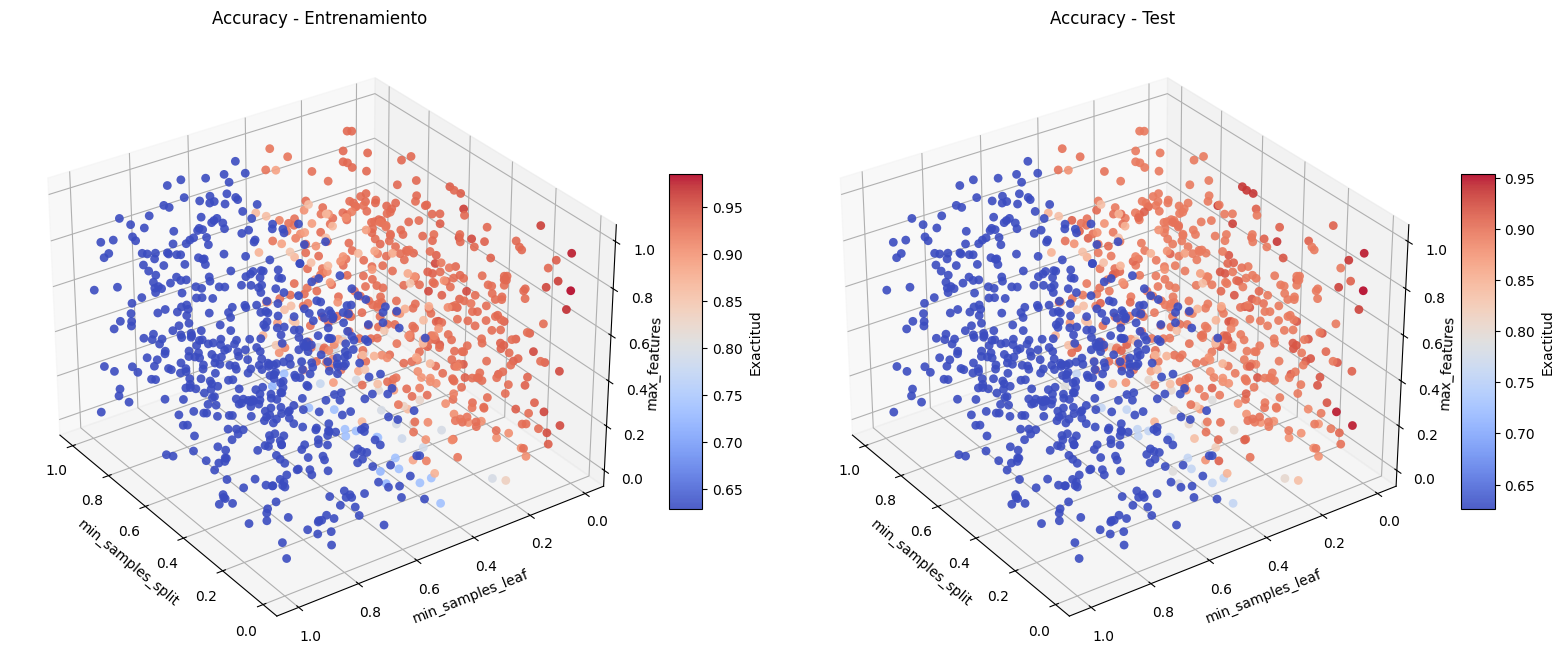

In [22]:
from matplotlib import cm

fig = plt.figure(figsize=(16, 7))

ax1 = fig.add_subplot(121, projection='3d')

# Usamos scatter con la paleta de colores coolwarm
sc1 = ax1.scatter(rango_min_samples_split, rango_min_samples_leaf, rango_max_features,
                  c=train_accuracies, cmap=cm.coolwarm, s=40, alpha=0.9, linewidth=0)

ax1.set_title("Accuracy - Entrenamiento")
ax1.set_xlabel("min_samples_split")
ax1.set_ylabel("min_samples_leaf")
ax1.set_zlabel("max_features", labelpad=-3)
fig.colorbar(sc1, ax=ax1, shrink=0.5, aspect=10, orientation='vertical', label="Exactitud")

# Ajustamos el ángulo de la cámara
ax1.view_init(None, 145)


ax2 = fig.add_subplot(122, projection='3d')

sc2 = ax2.scatter(rango_min_samples_split, rango_min_samples_leaf, rango_max_features,
                  c=test_accuracies, cmap=cm.coolwarm, s=40, alpha=0.9, linewidth=0)

ax2.set_title("Accuracy - Test")
ax2.set_xlabel("min_samples_split")
ax2.set_ylabel("min_samples_leaf")
ax2.set_zlabel("max_features", labelpad=-3) # Esto es para que la barra de exactitud no tape a 'max_features'
fig.colorbar(sc2, ax=ax2, shrink=0.5, aspect=10, orientation='vertical', label="Exactitud")

# Ajustamos el ángulo de la cámara
ax2.view_init(None, 145)

plt.tight_layout()
plt.show()

**APARTADOS B y C)**

Se ve claramente que hay una mejora en la precisión del clasificador a medida que se acerca max_features a 1 y disminuye min_samples_leaf.

El hiperparámetro más influyente en el rendimiento es **'min_samples_leaf'**.

## Ejercicio Experto

6. Cargue el conjunto de datos Breast Cancer que viene incorporado en sklearn. Haz una división en conjuntos de entrenamiento (70%) y test (30%), que usará en todo el ejercicio.

    **a)** Entrene diferentes máquinas de vectores soporte, usando el núcleo de función de base radial (Radial Basis Function, RBF). Pruebe con valores igualmente espaciados del parámetro de regularización C desde 0.01 hasta 5, y con valores igualmente espaciados del coeficiente del núcleo (gamma) desde 0.0001 hasta 0.01. Debe probar al menos 50 valores para C y 50 valores para gamma. Tenga en cuenta que debe probar las distintas combinaciones de valores de C y gamma, es decir, debe hacer al menos 50*50=2500 entrenamientos. No debería tardar más de 2 o 3 minutos en hacer los 2500 entrenamientos. Mida la exactitud (accuracy) para los conjuntos de entrenamiento y test. Una vez hechas todas estas pruebas, genere dos mapas de calor (conocidos como matrices de colores en las prácticas guiadas), uno para los resultados en entrenamiento y otro para los resultados en test, en los que se puedan visualizar los resultados obtenidos. El eje horizontal será el valor de gamma, y el eje vertical el valor de C. Recuerde que el color debe indicar el valor de la exactitud para el conjunto considerado (entrenamiento o test).

    **b)** ¿Se aprecia que el rendimiento del clasificador es sensible a los valores de C y gamma?

    **c)** Repita el apartado a, pero en este caso variando los intervalos de valores de C y gamma. Debe identificar en la gráfica obtenida en el apartado “a” una región del mapa de calor de la exactitud en test que sea prometedora, es decir, que contenga valores altos de exactitud en test, y usar dicha región para elegir los intervalos de valores de C y gamma. Dicho de otra manera, se trata de ampliar (zoom) una región prometedora del mapa de calor obtenido en el apartado “a”.

    **d)** ¿Qué se observa en el segundo mapa de calor? ¿Hay estabilidad en los resultados?

In [23]:
data_breast_cancer = load_breast_cancer()
X=data_breast_cancer['data']
y=data_breast_cancer['target']

# Dividimos el conjunto de muestras en 70% de entrenamiento y 30% de test

X_ent, X_test, y_ent, y_test =\
    train_test_split(X, y,
                     test_size=0.3,
                     random_state=10,
                     stratify=y)

In [24]:
# APARTADO A)

from sklearn.svm import SVC

n_iters = 50

rango_param_C = np.linspace(0.01, 5, n_iters)
rango_param_gamma = np.linspace(0.0001, 0.01, n_iters)

# Guardaremos los resultados en matrices de forma que sea más sencillo
# para después graficarlas
train_accuracies_matrix = np.zeros((n_iters, n_iters))
test_accuracies_matrix = np.zeros((n_iters, n_iters))

# Construyo un doble bucle con las configuraciones que hemos creado, entrenamos
# la SVM y calculamos su precisión en entrenamiento y test

for i in range(n_iters):
  for j in range(n_iters):

    svc = SVC(
        kernel='rbf',
        gamma=rango_param_gamma[j],
        C=rango_param_C[i],
        random_state=10
    )

    svc.fit(X_ent, y_ent)

    # Cálculo de precisión en entrenamiento y test
    train_acc = accuracy_score(y_ent, svc.predict(X_ent))
    test_acc = accuracy_score(y_test, svc.predict(X_test))

    train_accuracies_matrix[i, j] = train_acc
    test_accuracies_matrix[i, j] = test_acc

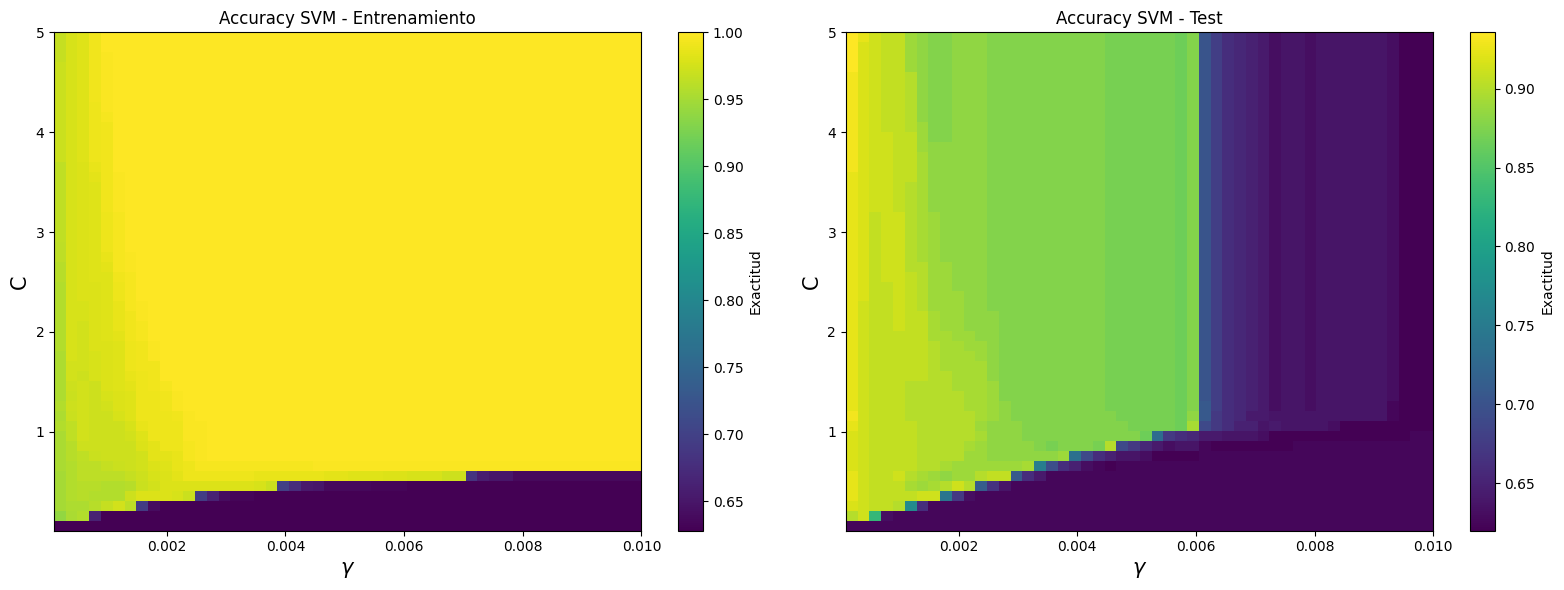

In [25]:
# Configuramos una figura con dos subgráficos, graficaremos las matrices
# de colores usando imshow()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Definimos los límites de los ejes: [0.0001, 0.01, 0.01, 5]
limites = [rango_param_gamma[0], rango_param_gamma[-1],
           rango_param_C[0], rango_param_C[-1]]

im1 = ax1.imshow(train_accuracies_matrix, aspect='auto',
                 origin='lower', extent=limites)

ax1.set_title("Accuracy SVM - Entrenamiento")
ax1.set_xlabel(r"$\gamma$", fontsize=15)
ax1.set_ylabel("C", fontsize=15)

fig.colorbar(im1, ax=ax1, label="Exactitud")

im2 = ax2.imshow(test_accuracies_matrix, aspect='auto',
                 origin='lower', extent=limites)

ax2.set_title("Accuracy SVM - Test")
ax2.set_xlabel(r"$\gamma$", fontsize=15)
ax2.set_ylabel("C", fontsize=15)
fig.colorbar(im2, ax=ax2, label="Exactitud")

plt.tight_layout()
plt.show()

**APARTADO B)**

Se aprecia totalmente. Cuanto más se acerca el valor de $\gamma$ a 0.0001, mejor precisión obtiene el clasificador en test.

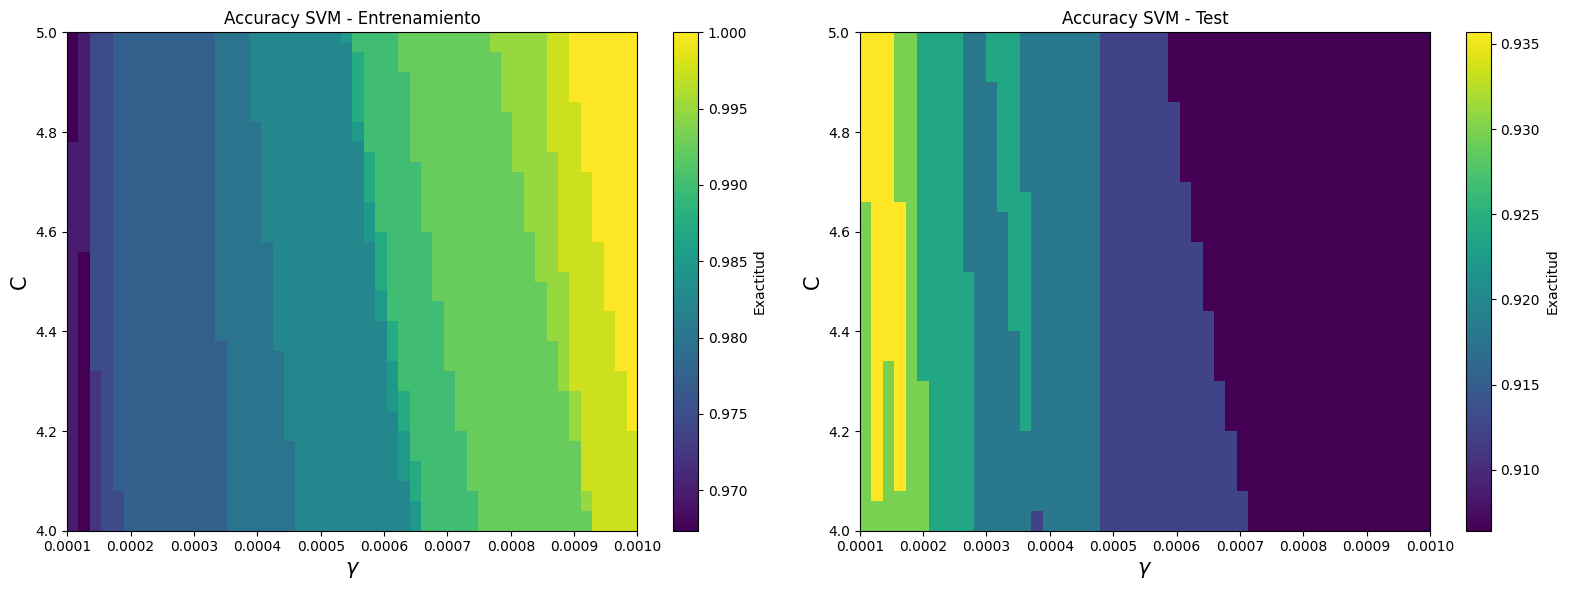

In [27]:
# APARTADO C)

# He decidido tomar valores de C entre 4 y 5 y valores de gamma entre 0.0001 y 0.001
# que es la región más prometedora en cuánto a exactitud

rango_param_C = np.linspace(4, 5, n_iters)
rango_param_gamma = np.linspace(0.0001, 0.001, n_iters)

# Guardaremos los resultados en matrices de forma que sea más sencillo
# para después graficarlas
train_accuracies_matrix = np.zeros((n_iters, n_iters))
test_accuracies_matrix = np.zeros((n_iters, n_iters))

# Construyo un doble bucle con las configuraciones que hemos creado, entrenamos
# la SVM y calculamos su precisión en entrenamiento y test

for i in range(n_iters):
  for j in range(n_iters):

    svc = SVC(
        kernel='rbf',
        gamma=rango_param_gamma[j],
        C=rango_param_C[i],
        random_state=10
    )

    svc.fit(X_ent, y_ent)

    # Cálculo de precisión en entrenamiento y test
    train_acc = accuracy_score(y_ent, svc.predict(X_ent))
    test_acc = accuracy_score(y_test, svc.predict(X_test))

    train_accuracies_matrix[i, j] = train_acc
    test_accuracies_matrix[i, j] = test_acc


# Configuramos una figura con dos subgráficos, graficaremos las matrices
# de colores usando imshow()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Definimos los límites de los ejes: [0.0001, 0.01, 0.01, 5]
limites = [rango_param_gamma[0], rango_param_gamma[-1],
           rango_param_C[0], rango_param_C[-1]]

im1 = ax1.imshow(train_accuracies_matrix, aspect='auto',
                 origin='lower', extent=limites)

ax1.set_title("Accuracy SVM - Entrenamiento")
ax1.set_xlabel(r"$\gamma$", fontsize=15)
ax1.set_ylabel("C", fontsize=15)

fig.colorbar(im1, ax=ax1, label="Exactitud")

im2 = ax2.imshow(test_accuracies_matrix, aspect='auto',
                 origin='lower', extent=limites)

ax2.set_title("Accuracy SVM - Test")
ax2.set_xlabel(r"$\gamma$", fontsize=15)
ax2.set_ylabel("C", fontsize=15)
fig.colorbar(im2, ax=ax2, label="Exactitud")

plt.tight_layout()
plt.show()

**APARTADO D)**

En este segundo mapa de calor se observa que el rendimiento del modelo está dominado casi por completo por el parámetro $\gamma$. Las franjas de exactitud en el conjunto de test son verticales, lo que indica que variaciones en $C$ apenas afectan al resultado, mientras que variaciones en $\gamma$ son críticas.

**Sí**, se observa estabilidad, pero restringida a una zona muy concreta: la franja izquierda donde $\gamma$ toma valores entre 0.0001 y 0.0002. En esa región, el modelo alcanza su máxima exactitud en test y se mantiene estable independientemente del valor de $C$.